In [144]:
import os
from pathlib import Path

import geopandas as gpd
import libpysal
import matplotlib.pyplot as plt
import rasterio as rio
import rasterio.features as rio_features
import shapely
from esda.getisord import G_Local
from sklearn.datasets import make_blobs
import contextily as cx

In [93]:
X, _ = make_blobs(1000, centers=[[1, 2], [2, 3]])

In [94]:
X.shape

(1000, 2)

In [95]:
data_path = Path(os.environ["DATA_PATH"])

In [96]:
bounds = gpd.read_file(data_path / "lim_aumxl24").to_crs("EPSG:4326")["geometry"].item()

In [110]:
with rio.open("./final_raster_summer.tif") as ds:
    data = ds.read(1)
    data[data == ds.nodata] = 0
    transform = ds.transform
    mask = data != 0
    df_geom = [
        (shapely.geometry.shape(j), v)
        for j, v in rio_features.shapes(
            data, connectivity=8, transform=transform, mask=mask,
        )
    ]
    df_geom = gpd.GeoDataFrame(df_geom, crs=ds.crs, columns=["geometry", "value"], geometry="geometry")

df_geom = df_geom.to_crs("EPSG:6372").reset_index(names="index")

# Getis-Ord

In [104]:
w = libpysal.weights.Queen.from_dataframe(df_geom)
g = G_Local(df_geom["value"], w, transform="B")

/var/folders/yq/0mz24vy927s9m5vjh6gqb6040000gn/T/ipykernel_18152/716572705.py:1: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = libpysal.weights.Queen.from_dataframe(df_geom)


In [ ]:
sig = g.p_sim < 0.05
hh = df_geom.loc[(g.Zs > 0) & (sig == True)]

hh_cat = (
    hh
    .assign(
        component=libpysal.weights.Queen.from_dataframe(hh).component_labels,
    )
    .dissolve(
        by="component", 
        aggfunc={"value": "median", "index": list},
    )
)

/var/folders/yq/0mz24vy927s9m5vjh6gqb6040000gn/T/ipykernel_18152/4012379008.py:7: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  component=libpysal.weights.Queen.from_dataframe(hh).component_labels,
/Users/rodolfofigueroa/Documents/mexicali-zone/.venv/lib/python3.11/site-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 261 disconnected components.
 There are 18 islands with ids: 477, 1129, 1896, 1997, 2162, 3629, 5398, 9781, 14639, 15214, 15260, 16780, 17711, 31149, 32016, 34530, 34545, 37639.
  W.__init__(self, neighbors, ids=ids, **kw)


In [147]:
area_thresh = 0.5 * 1e6
components = hh_cat[hh_cat.area > area_thresh]
component_idx = set(components["index"].sum())

hh_filtered = hh.query("index.isin(@component_idx)").to_crs("EPSG:4326")

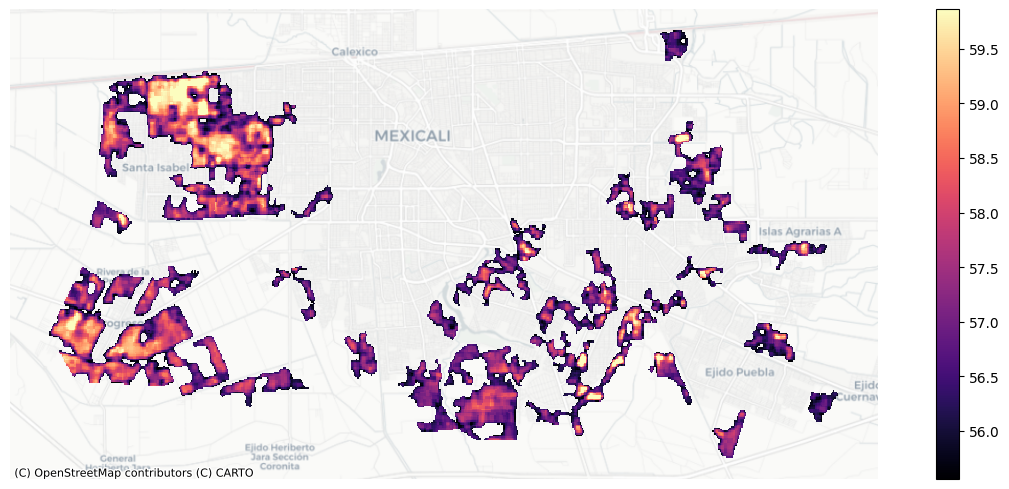

In [154]:
vmin = hh_filtered["value"].quantile(0.02)
vmax = hh_filtered["value"].quantile(0.98)

fig, ax = plt.subplots(figsize=(12, 5))
hh_filtered.plot(column="value", ax=ax, lw=0, ec="none", legend=True, vmin=vmin, vmax=vmax, cmap="magma")
cx.add_basemap(ax, source=cx.providers.CartoDB.Positron, crs=hh_filtered.crs)
ax.axis("off")
fig.tight_layout()

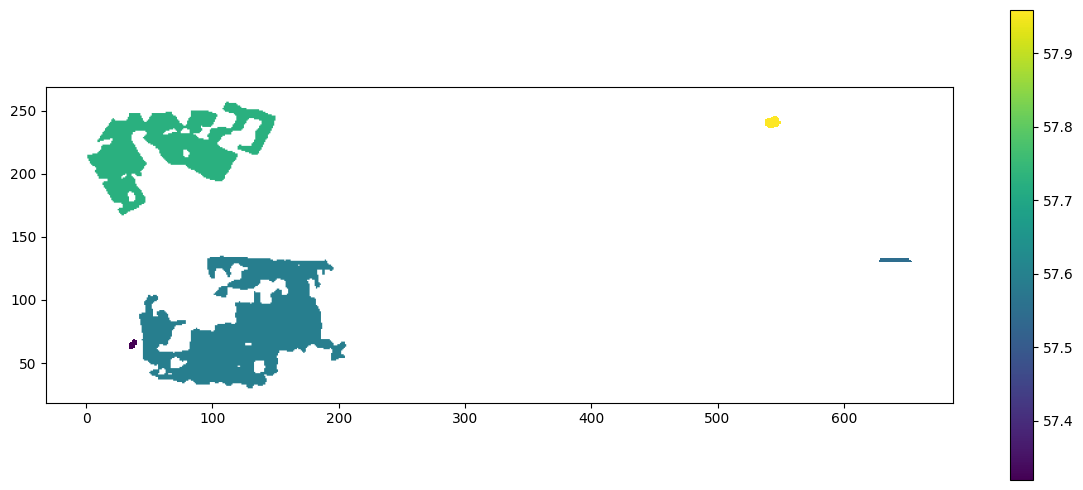

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
hh.sort_values("value", ascending=False).head(5).plot(
    column="value",
    legend=True,
    ax=ax,
)
fig.tight_layout()

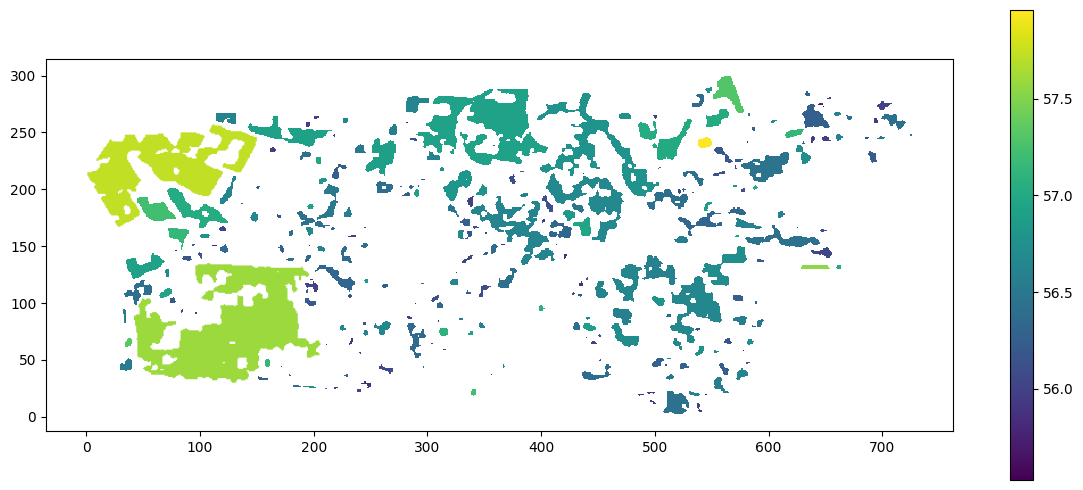

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
hh.plot(column="value", legend=True, ax=ax, cmap="viridis")
fig.tight_layout()

In [ ]:
w = libpysal.weights.Queen.from_dataframe(gdf)

/var/folders/yq/0mz24vy927s9m5vjh6gqb6040000gn/T/ipykernel_18152/2898234147.py:1: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = libpysal.weights.Queen.from_dataframe(gdf)
